# General Parameters

In [1]:
### Load Python Lib##### 
### plot_FFcompsr_Q2max.py
### Plot form factor ratios vs. Q^2max for fits w/, w/o sum rules with stat errors.
########
import numpy as np
from math import *
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.ticker import FixedLocator, MultipleLocator, FormatStrFormatter
import os, sys, traceback

#very import to enable this so the plots can be showed in the page
get_ipython().magic(u'matplotlib inline')

# Use LaTeX font.
plt.rc('text', usetex=True)
plt.rc('font',**{'family':'serif','serif':['Computer Modern Roman'],'size':20})

import matplotlib.font_manager as font_manager
font_prop = font_manager.FontProperties( size=12)

In [2]:
## Input Parameters
Q2max = 1000
Q2str = str(Q2max)
Q2plot =10000
kmax = 12
#kmax=int(sys.argv[1])

fitdata = 'world'
#Q2max = int(raw_input('Max Q2 Fit =  '))
#Q2plot = float(raw_input('Max Q2 Plot = '))
#kmax = int(raw_input('Max Z = '))

bnd = '5'
mod = 't0fix7'

# Load Data

In [3]:
## Dipole FF
Lambda2 = 0.71
GEn0 = 1
GMn0 = -1.91304272
def GD(Q2):
    return 1./(1+Q2/Lambda2)**2


## Load $G_E^n$ Sum-Rules baseline Fitting Results w/ radius constraints

In [4]:
kmax=10
##Load Q2max=1000 Fitting results#{{{
folder = './z'+str(kmax) # folder containing central fits
#filename=folder+'/Round6_world_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+mod+'_GEn.dat'
filename=folder+'/out_world_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+mod+'_GEn.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2e_n = np.zeros(N, dtype=float)
Ze_n = np.zeros(N, dtype=float)
GE_fit_n = np.zeros(N, dtype=float)
GE_pos_n = np.zeros(N, dtype=float)
GE_neg_n = np.zeros(N, dtype=float)
GErat_fit_n = np.zeros(N, dtype=float)
GErat_pos_n = np.zeros(N, dtype=float)
GErat_neg_n = np.zeros(N, dtype=float)
GED_n = np.zeros(N, dtype=float)
dGEnGD = np.zeros(N, dtype=float)

for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2e_n[i]=float(values[0])
    Ze_n[i]=float(values[1])
    GE_fit_n[i]=float(values[2])
    GE_pos_n[i]=float(values[2])+abs(float(values[3]))
    GE_neg_n[i]=float(values[2])-abs(float(values[3]))
    Gdip = float(values[4])
#    Gdip = 1./(1.+float(values[0])/0.71)**2
    GED_n[i]=Gdip*GEn0
    GErat_fit_n[i]=GE_fit_n[i]/GED_n[i]
    GErat_pos_n[i]=GE_pos_n[i]/GED_n[i]
    GErat_neg_n[i]=GE_neg_n[i]/GED_n[i] 
#}}}

file exist ./z10/out_world_sumrules_leastsq_Q21000_z10_gb5_t0fix7_GEn.dat


## Load $G_E^n$ Sum-Rules  Fitting Results w/o radius constraints

In [5]:
kmax=10
##Load Q2max=1000 Fitting results#{{{
folder = './z'+str(kmax) # folder containing central fits
#filename=folder+'/Round6_world_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+mod+'_GEn_noRad.dat'
filename=folder+'/out_world_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+mod+'_GEn_noRad.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2e_n1 = np.zeros(N, dtype=float)
Ze_n1 = np.zeros(N, dtype=float)
GE_fit_n1 = np.zeros(N, dtype=float)
GE_pos_n1 = np.zeros(N, dtype=float)
GE_neg_n1 = np.zeros(N, dtype=float)
GErat_fit_n1 = np.zeros(N, dtype=float)
GErat_pos_n1 = np.zeros(N, dtype=float)
GErat_neg_n1 = np.zeros(N, dtype=float)
GED_n1 = np.zeros(N, dtype=float)

for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2e_n1[i]=float(values[0])
    Ze_n1[i]=float(values[1])
    GE_fit_n1[i]=float(values[2])
    GE_pos_n1[i]=float(values[2])+abs(float(values[3]))
    GE_neg_n1[i]=float(values[2])-abs(float(values[3]))
    Gdip = float(values[4])
    #Gdip = 1./(1.+float(values[0])/0.71)**2
    GED_n1[i]=Gdip*GEn0   
    GErat_fit_n1[i]=GE_fit_n1[i]/GED_n1[i]
    GErat_pos_n1[i]=GE_pos_n1[i]/GED_n1[i]
    GErat_neg_n1[i]=GE_neg_n1[i]/GED_n1[i] 

#}}}

file exist ./z10/out_world_sumrules_leastsq_Q21000_z10_gb5_t0fix7_GEn_noRad.dat


## Load $G_M^n$ Sum-Rules baseline Fitting Results w/ radius constraints

In [6]:
kmax=10
##Load Q2max=1000 Fitting results#{{{
folder = './z'+str(kmax) # folder containing central fits
#filename=folder+'/Round6_world_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+mod+'_GMn.dat'
filename=folder+'/out_world_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+mod+'_GMn.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2m_n = np.zeros(N, dtype=float)
Zm_n = np.zeros(N, dtype=float)
GM_fit_n = np.zeros(N, dtype=float)
GM_pos_n = np.zeros(N, dtype=float)
GM_neg_n = np.zeros(N, dtype=float)
GMrat_fit_n = np.zeros(N, dtype=float)
GMrat_pos_n = np.zeros(N, dtype=float)
GMrat_neg_n = np.zeros(N, dtype=float)
GMD_n = np.zeros(N, dtype=float)
dGMnGD = np.zeros(N, dtype=float)

for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2m_n[i]=float(values[0])
    Zm_n[i]=float(values[1])
    GM_fit_n[i]=float(values[2])
    GM_pos_n[i]=float(values[2])+abs(float(values[3]))
    GM_neg_n[i]=float(values[2])-abs(float(values[3]))
    #Gdip = 1./(1.+float(values[0])/0.71)**2
    Gdip = float(values[4])
    GMD_n[i]=Gdip*GMn0       
    GMrat_fit_n[i]=GM_fit_n[i]/GMD_n[i]
    GMrat_pos_n[i]=GM_pos_n[i]/GMD_n[i]
    GMrat_neg_n[i]=GM_neg_n[i]/GMD_n[i] 
#}}}

file exist ./z10/out_world_sumrules_leastsq_Q21000_z10_gb5_t0fix7_GMn.dat


## Load $G_M^n$ Sum-Rules  Fitting Results w/o radius constraints

In [7]:
kmax=10
##Load Q2max=1000 Fitting results#{{{
folder = './z'+str(kmax) # folder containing central fits
#filename=folder+'/Round6_world_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+mod+'_GMn_noRad.dat'
filename=folder+'/out_world_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+mod+'_GMn_noRad.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2m_n1 = np.zeros(N, dtype=float)
Zm_n1 = np.zeros(N, dtype=float)
GM_fit_n1 = np.zeros(N, dtype=float)
GM_pos_n1 = np.zeros(N, dtype=float)
GM_neg_n1 = np.zeros(N, dtype=float)
GMrat_fit_n1 = np.zeros(N, dtype=float)
GMrat_pos_n1 = np.zeros(N, dtype=float)
GMrat_neg_n1 = np.zeros(N, dtype=float)
GMD_n1 = np.zeros(N, dtype=float)

for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2m_n1[i]=float(values[0])
    Zm_n1[i]=float(values[1])
    GM_fit_n1[i]=float(values[2])
    GM_pos_n1[i]=float(values[2])+abs(float(values[3]))
    GM_neg_n1[i]=float(values[2])-abs(float(values[3]))
#    Gdip = 1./(1.+float(values[0])/0.71)**2
    Gdip = float(values[4])
    GMD_n1[i]=Gdip*GMn0
    GMrat_fit_n1[i]=GM_fit_n1[i]/GMD_n1[i]
    GMrat_pos_n1[i]=GM_pos_n1[i]/GMD_n1[i]
    GMrat_neg_n1[i]=GM_neg_n1[i]/GMD_n1[i] 

#}}}

file exist ./z10/out_world_sumrules_leastsq_Q21000_z10_gb5_t0fix7_GMn_noRad.dat


# Calculating Errors 

In [9]:
## Model Dependent Errors by using different data sets

GE_err_fit = np.zeros(len(Q2e_n), dtype=float)
GM_err_fit = np.zeros(len(Q2e_n), dtype=float)
GE_err_sum = np.zeros(len(Q2e_n), dtype=float)
GM_err_sum = np.zeros(len(Q2e_n), dtype=float)
GE_err_rh = np.zeros(len(Q2e_n), dtype=float)
GM_err_rh = np.zeros(len(Q2e_n), dtype=float)
GE_fit_rh = np.zeros(len(Q2e_n), dtype=float)
GM_fit_rh = np.zeros(len(Q2e_n), dtype=float)
of = open('neutron_baseline.dat','w')
print >> of, '##%10s %14s %14s %14s %14s %14s %14s'%('Q2','GEn/GD','dGEn/GD','dGEn_Par/GD','GMn/muGD','dGMn/muGD','dGMn_Par/muGD')

from GetFF import *
for i in range(0, len(Q2e_n)):    
        GE_err_fit[i] = abs(GErat_pos_n[i] - GErat_fit_n[i])# use the central fit values w/ radius constraint
        GE_err_sum[i] = abs(GErat_pos_n[i] - GErat_fit_n[i])# use the error also w/ radius contraints

        GM_err_fit[i] = abs(GMrat_pos_n[i]  - GMrat_fit_n[i]) # use the central fit values w/ radius constraint
        GM_err_sum[i] = abs(GMrat_pos_n1[i] - GMrat_fit_n1[i]) # use the error w/o radius contraints
      
        GE_fit_rh[i], GE_err_rh[i] = GetFF(3, Q2e_n[i])
        GM_fit_rh[i], GM_err_rh[i] = GetFF(4, Q2e_n[i])

        #GE_err_rh[i] = dG_RH(Q2e_n[i], Einf_GEn, c0_GEn5, c_GEn5, d_GEn5, L_GEn5 ) #/abs(GEn0)
        #GM_err_rh[i] = dG_RH(Q2e_n[i], Einf_GMn, c0_GMn5, c_GMn5, d_GMn5, L_GMn5 ) #/abs(GMp0)      
        #GE_err_rh[i] = dG_RH(Q2e_n[i], Einf_GEn, c0_GEn, c_GEn, d_GEn, L_GEn ) #/abs(GEn0)
        #GM_err_rh[i] = dG_RH(Q2e_n[i], Einf_GMn, c0_GMn, c_GMn, d_GMn, L_GMn ) #/abs(GMn0)
        
        #print >> of, '%12.4e %14.6e %14.6e %14.6e %14.6e %14.6e %14.6e'%(Q2e_n[i], GErat_fit_n[i], GE_err_sum[i], GE_err_rh[i],GMrat_fit_n[i], GM_err_sum[i], GM_err_rh[i]  )
        print >> of, '%12.4e %14.6e %14.6e %14.6e %14.6e %14.6e %14.6e'%(Q2e_n[i], GE_fit_rh[i], GE_err_sum[i], GE_err_rh[i],GM_fit_rh[i], GM_err_sum[i], GM_err_rh[i]  )
of.close()
        

# Plot Errors

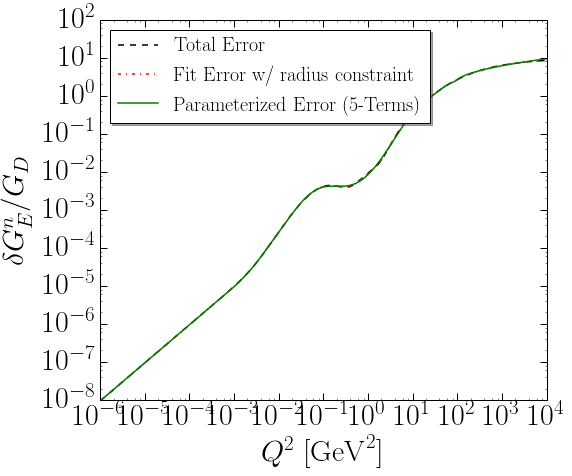

In [10]:
f1, axes = plt.subplots(nrows=1, ncols=1, figsize=(8,6))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#######  Subplot for GE/GD.
axes.plot(Q2e_n, GE_err_sum, 'k--', color='black',  label='Total Error', linewidth=1.5)
axes.plot(Q2e_n, GE_err_fit, 'k-.', color='r',  label='Fit Error w/ radius constraint', linewidth=1.5)
axes.plot(Q2e_n, GE_err_rh, 'k-', color='g',  label='Parameterized Error (5-Terms)', linewidth=1.5)

axes.set_xlim(1e-6, 1e4)
axes.set_ylim(1e-8, 100)
axes.set_xscale('log')
axes.set_yscale('log')

axes.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=30)
axes.set_ylabel('$\delta G_E^n/G_{D}$', fontsize=30)

lg= axes.legend(loc='upper left', shadow='true', fontsize='medium', numpoints=1)
axes.xaxis.set_tick_params(width=1, length=7)
axes.yaxis.set_tick_params(width=1, length=7)
plt.tick_params(labelsize=30)

#plt.savefig('GEn_Error_Curves_round6.pdf',bbox_inches='tight')
plt.savefig('GEn_Error_Curves_precise.pdf',bbox_inches='tight')

# plt.savefig('GEn_Error_Curves_seg5.eps',bbox_inches='tight')
# plt.savefig('GEn_Error_Curves_seg5.png',bbox_inches='tight')

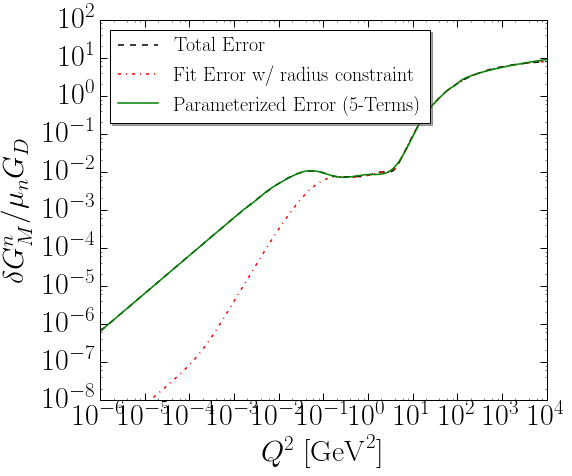

In [11]:
f1, axes = plt.subplots(nrows=1, ncols=1, figsize=(8,6))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#######  Subplot for GE/GD.
axes.plot(Q2e_n, GM_err_sum, 'k--', color='black',  label='Total Error', linewidth=1.5)
axes.plot(Q2e_n, GM_err_fit, 'k-.', color='r',  label='Fit Error w/ radius constraint', linewidth=1.5)
axes.plot(Q2e_n, GM_err_rh, 'k-', color='g',  label='Parameterized Error (5-Terms)', linewidth=1.5)

axes.set_xlim(1e-6, 1e4)
axes.set_ylim(1e-8, 100)
axes.set_xscale('log')
axes.set_yscale('log')

axes.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=30)
axes.set_ylabel('$\delta G_M^n/\mu_n G_{D}$', fontsize=30)
#axes.set_ylabel('$\delta G_M^n/G_{D}$', fontsize=30)

lg= axes.legend(loc='upper left', shadow='true', fontsize='medium', numpoints=1)
axes.xaxis.set_tick_params(width=1, length=7)
axes.yaxis.set_tick_params(width=1, length=7)
plt.tick_params(labelsize=30)

#plt.savefig('GMn_Error_Curves_round6.pdf',bbox_inches='tight')
plt.savefig('GMn_Error_Curves_precise.pdf',bbox_inches='tight')

# plt.savefig('GMn_Error_Curves_seg5.eps',bbox_inches='tight')
# plt.savefig('GMn_Error_Curves_seg5.png',bbox_inches='tight')

# Ploting Central Curves

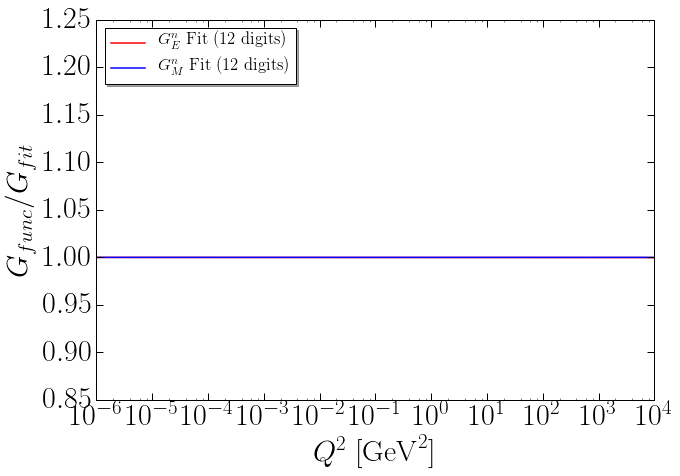

In [13]:
## 

f1, axes = plt.subplots(nrows=1, ncols=1, figsize=(10,6))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)
ND=12
#######  Subplot for GE/GD.
axes.plot(Q2e_n, GE_fit_rh/(GErat_fit_n), 'k-', color='r',  label='$G_E^n$ Fit (%d digits)'%ND, linewidth=1.5)

axes.plot(Q2e_n, GM_fit_rh/(GMrat_fit_n), 'k-', color='b',  label='$G_M^n$ Fit (%d digits)'%ND, linewidth=1.5)

#axes.set_xlim(2000, 2200)
axes.set_ylim(0.85, 1.25)
axes.set_xscale('log')
#axes.set_yscale('log')

axes.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=30)
axes.set_ylabel('$G_{func}/G_{fit}$', fontsize=30)

lg= axes.legend(loc='upper left', shadow='true', fontsize='small', numpoints=1)
#lg= axes.legend(loc=' right', shadow='true', fontsize='small', numpoints=1)

axes.xaxis.set_tick_params(width=1, length=7)
axes.yaxis.set_tick_params(width=1, length=7)
plt.tick_params(labelsize=30)

plt.savefig('neutron_central_curve_%d_digits.pdf'%ND,bbox_inches='tight')
